In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [9]:
# LOAD MNIST

In [8]:
(x_train, y_train), (x_test, y_test) = \
tf.keras.datasets.mnist.load_data()
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [10]:
# NORMALIZE THE IMAGES

In [12]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [13]:
# ADD CHANNEL DIMENSION

In [14]:
x_train = x_train[..., None]
x_test = x_test[..., None]
print(x_train.shape)

(60000, 28, 28, 1)


In [15]:
#BUILD THE CNN

In [20]:
model = models.Sequential([
    layers.Conv2D(
        32,
        (3, 3),
        activation = "relu",
        input_shape = (28, 28, 1)
    ),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(
        128,
        activation="relu"
    ),
    layers.Dense(
        10,
        activation="softmax"
    )
])

In [21]:
# UNDERSTAND THE ARCHITECTURE

In [23]:
layers.Conv2D(32, (3, 3), activation="relu")

<Conv2D name=conv2d_6, built=False>

In [24]:
layers.MaxPooling2D((2, 2))

<MaxPooling2D name=max_pooling2d_5, built=True>

In [25]:
layers.Conv2D(64, (3, 3), activation="relu")

<Conv2D name=conv2d_7, built=False>

In [26]:
layers.Flatten()

<Flatten name=flatten_2, built=False>

In [27]:
layers.Dense(128, activation="relu")

<Dense name=dense_4, built=False>

In [29]:
layers.Dense(10, activation="softmax")

<Dense name=dense_6, built=False>

In [30]:
#COMPILE THE CNN

In [31]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
# VIEW MODEL ARCHITECTURE

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#TRAIN THE CNN

In [35]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9513 - loss: 0.1643 - val_accuracy: 0.9852 - val_loss: 0.0504
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9841 - loss: 0.0507 - val_accuracy: 0.9848 - val_loss: 0.0544
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.9890 - loss: 0.0359 - val_accuracy: 0.9895 - val_loss: 0.0381
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.9917 - loss: 0.0252 - val_accuracy: 0.9918 - val_loss: 0.0296
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.9937 - loss: 0.0193 - val_accuracy: 0.9902 - val_loss: 0.0346


In [36]:
#EVALUATE THE CNN

In [37]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9908 - loss: 0.0277
Test Accuracy: 0.9908000230789185


In [38]:
#PREDICT A NEW IMAGE

In [40]:
import numpy as np
image = x_test[0]
prediction = model.predict(
    image[np.newaxis, ...]
)
predicted_digit = np.argmax(prediction)
print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Predicted Digit: 7
Actual Digit: 7


In [41]:
# DISPLAY THE IMAGE

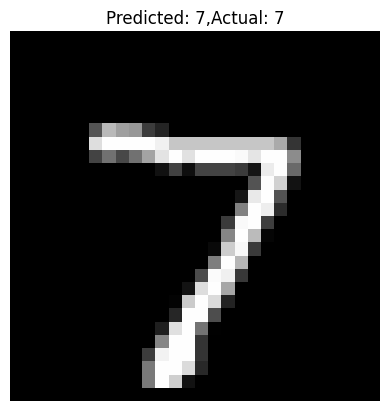

In [47]:
 plt.imshow(
     x_test[0].squeeze(),
     cmap="gray"
 )
 plt.title(
          f"Predicted: {predicted_digit},"
     f"Actual: {y_test[0]}"
 )
 plt.axis("off")
 plt.show()
